In [1]:
from wilson.dataanalysis import *
import matplotlib.pyplot as plt
%matplotlib inline
from wilson.spectrum_generator import make_name, make_texts4fig

np.set_printoptions(precision=4)
import os

In [2]:
log10=True
w1mw2=False
broad_factor_rc=10.

# terms_selection = [0, 1], [0, 1, 2, 3, 4, 5]
terms_selection = [0, 1], [0, 1]

regions = {1: ((1280., 3150., 10.), (1589., 6050., 10.)),
           2: ((2526.813, 2860., 10.), (5210., 5550., 10.)),
           3: ((2645., 2785., 10.), (3825., 4625., 10.)),
           4: ((680., 1750., 10.), (1509., 4350., 10.)),
           5: ((680., 1750., 10.), (1509., 3050., 10.))}

# template
settings_here = {'electrical': None, 'mechanical': None,
                 'Gamma_rc': broad_factor_rc, 'region': 2,
                 'font_dict': {'size': 18}, 'figsize': (12, 15), 'norm_max': 1e11}

spectra_dict = {"software": [], "code": [], "method": [], "basis_set": [],
                "el+mech max": [], "el max": [], "mech max": []}

other = {'regions': regions, 'terms_selection': terms_selection, 'w1mw2': False, 'log10': True}

from wilson.spectrum import getting_files_DB

dataframe_gaussian = getting_files_DB("gaussian")
print(dataframe_gaussian)
method_basis = dataframe_gaussian[(dataframe_gaussian['code'] == 'ACDM') & (dataframe_gaussian['method'] != 'PBE0')][["code", "method", "basis_set"]]
tuples_method_basis = [(row['code'], row['method'], row['basis_set']) for index, row in method_basis.iterrows()]
print(tuples_method_basis)

    code method                       basis_set                                                                                                  g16_3quanta_full
0   FORM     HF                         cc_pVDZ                          /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVDZ/g16_inputFull_3q.out
1   FORM     HF                    cc_pVDZ_VPT2                     /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVDZ_VPT2/g16_inputFull_3q.out
2   FORM     HF                         cc_pVTZ                          /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVTZ/g16_inputFull_3q.out
3   FORM     HF                         cc_pVQZ                          /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVQZ/g16_inputFull_3q.out
4   FORM     HF                    cc_pVQZ_VPT2                     /mnt/c/Users/vle014/Downloads/files_fram/dftGaussian/FORM/HFcc_pVQZ_VPT2/g16_inputFull_3q.out
5   FORM     HF             


Used vibrational energy levels:
 harmonic? - False
{'0': 3087.616, '1': 3080.223, '2': 2706.617, '3': 3030.509, '4': 3032.389, '5': 2938.859, '6': 2946.239, '7': 2537.516, '8': 1774.116, '9': 1730.646, '10': 1573.474, '11': 1562.815, '12': 1562.749, '13': 1559.613, '14': 1540.982, '15': 1531.62, '16': 1513.695, '17': 1510.147, '18': 1412.332, '19': 1385.906, '20': 1206.181, '21': 1169.709, '22': 1126.599, '23': 1131.979, '24': 1117.345, '25': 1120.352, '26': 931.713, '27': 930.113, '28': 716.49, '29': 716.705, '30': 680.892, '31': 671.568, '32': 545.143, '33': 492.492, '34': 270.295, '35': 266.463, '36': 223.427, '37': 199.938, '38': 169.035, '39': 186.123, '40': 149.653, '41': 118.644}
[118.644, 149.653, 169.035, 186.123, 199.938, 223.427, 266.463, 270.295, 492.492, 545.143, 671.568, 680.892, 716.49, 716.705, 930.113, 931.713, 1117.345, 1120.352, 1126.599, 1131.979, 1169.709, 1206.181, 1385.906, 1412.332, 1510.147, 1513.695, 1531.62, 1540.982, 1559.613, 1562.749, 1562.815, 1573.474, 

/home/vlew/Wilson/src/wilson/spectrum.py:389: UserWarning: Log scale: values of z <= 0 have been masked
  cont = plt.contourf(self.X, self.Y, self.intensities,


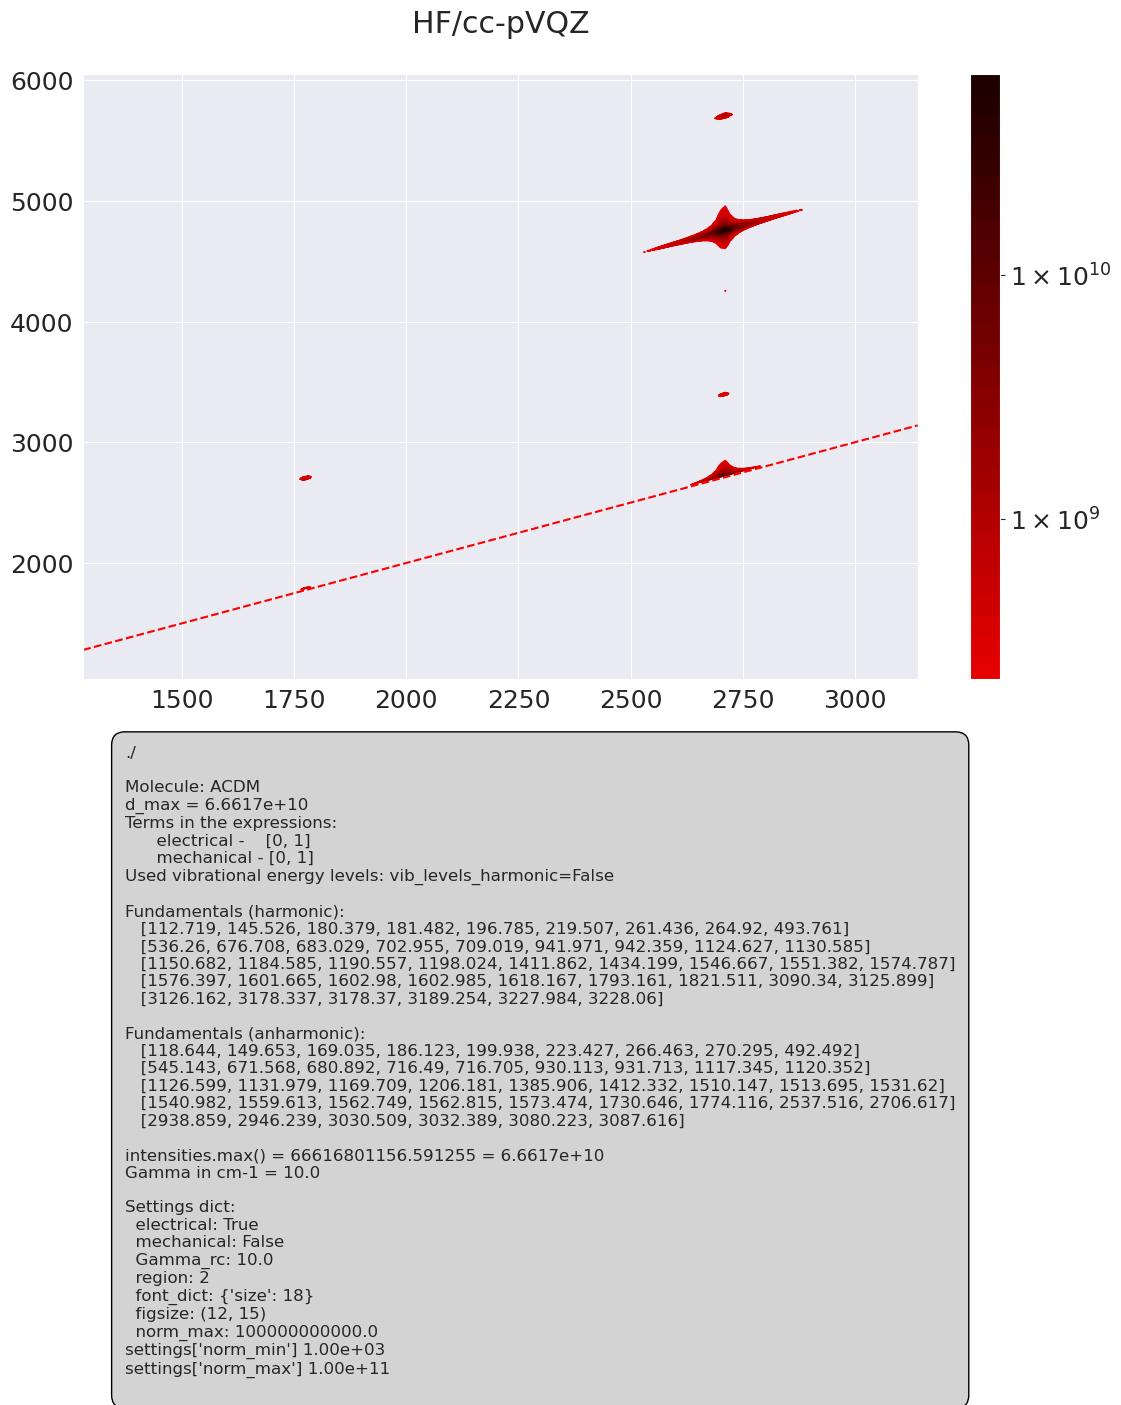

In [3]:
# selection of the spectrum
datain = spectrum.make_DatainputDict('gaussian', ('ACDM', 'HF', 'cc_pVQZ'))
# list_figs = [(True, False), (False, True), (True, True)]
list_figs = [(True, False)]
region = 1
omega1 = np.arange(*regions[region][0])
omega2 = np.arange(*regions[region][1])
# omega1 = [1185.288, 1247.878, 1501.586]
# omega2 = [2687.219, 2491.481, 2364.564]

for s in list_figs:
    settings_here['electrical'] = s[0]
    settings_here['mechanical'] = s[1]
    vibEL=False
    directory='./'
    
    region = settings_here['region']
    Gamma_rc = settings_here['Gamma_rc']
    el_bool = settings_here['electrical']
    mech_bool = settings_here['mechanical']

    computedSpectrum = spectrum.SpectrumEVV(omega1, omega2, input_data_info=datain, vib_levels_harmonic=vibEL)
    computedSpectrum.addTerms(*terms_selection)
    print(computedSpectrum.fundamentals)
    print(sorted(list(computedSpectrum.fundamentals.values())))
    # print(computedSpectrum.tensor_3d.T)
    Gamma = spectrum.rec_cm2rec_s(Gamma_rc)
    # sec_hypol_data, savedict = computedSpectrum.intensity(Gamma, {}, el=el_bool, mech=mech_bool)

    sec_hypol_data = 0
    if settings_here['electrical']:
        sec_hypol_data += computedSpectrum.intensity_electrical(Gamma)

    if settings_here['mechanical']:
        mechall, Qabc_contrib_dict = computedSpectrum.intensity_mechanical(Gamma)
        template_array = np.full(mechall.shape, -0.+0.j, dtype=complex)
        sec_hypol_data += mechall

    name = make_name(datain, vibEL, settings_here, other, directory)
    artist = spectrum.SpectrumFigure(sec_hypol_data, computedSpectrum.w1_mesh, computedSpectrum.w2_mesh, settings_here)
    title_on_top, text_under_the_figure = make_texts4fig(datain, computedSpectrum, artist, settings_here, other, directory)
    fig = artist.plot2Dmatplotlib(nametuple=(name, os.path.join(os.path.dirname('__file__')), title_on_top),
                                    text_under_the_figure=text_under_the_figure, to_save=False)
    plt.show()